# Randomness, Random Walks, and Monte Carlo Methods

In physics, we often encounter processes which are inherently random (e.g. radioactive decay), or which lend themselves to modeling as a random process (e.g. Brownian motion).  We can analyze such processes, making use of so-called "random number generators."

## Random number generators

The term "random number generator" is a bit misleading.  They are in fact completely deterministic, but produce a sequence of numbers which have very little correlation to one another.  

A well-known example is the linear congruential random number generator.  The basis of this generator is the equation $$x^{\prime} = (ax+c) \mathrm{~mod~}m,\tag{1}$$ where $a$, $c$, and $m$ are integer constants.  Given some input integer $x$, this formula calculates a new integer $x^{\prime}$.  Plugging this integer into the equation (as $x$) will result in yet another integer.  If we repeat this process many times, the sequence of integers that results is pseudorandom.

Here is an implementation of the linear congruential random number generator:

Text(0, 0.5, 'Random Number')

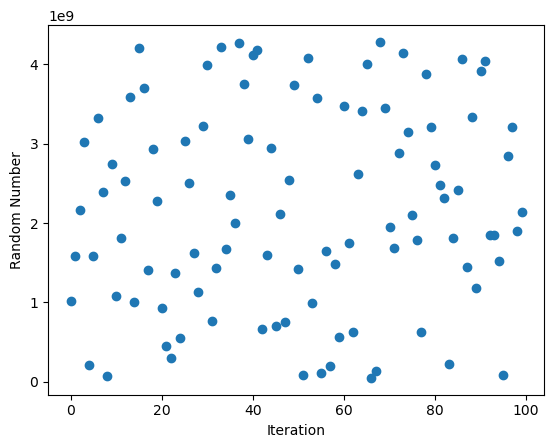

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#parameters of the generator - these have been chosen carefully to yield satisfactory performance
a = 1664525
c = 1013904223
m = 4294967296

N = 100 #how many numbers to generate
x = 1 #starting value

results = np.empty(N)

for i in range(N):
    x = (a*x+c)%m
    results[i] = x

plt.figure()
plt.plot(results,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

As can be seen from this plot, the resulting random numbers are (largely) uncorrelated.  The numbers are always positive, and because they are calculated modulo $m$, they can never be larger than this value ($4.29\times10^9$).  If we want random numbers within some alternate range, we can obtain them with minimal effort.  For example, if we need random numbers between 0 and 1, we could simply divide each of the above random numbers by $m$.

Text(0, 0.5, 'Random Number')

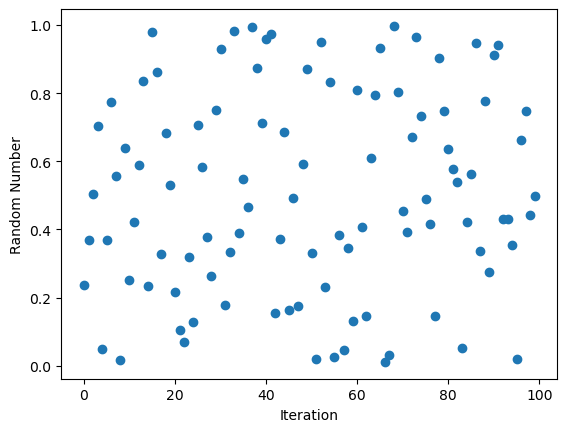

In [2]:
x = 1 #starting value

results = np.empty(N)

for i in range(N):
    x = (a*x+c)%m
    results[i] = x

plt.figure()
plt.plot(results/m,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

### Built-in random number generators

Python includes several varieties of random number generators.  While more sophisticated than the linear congruential random number generator above, they are also merely pseudorandom.

Documentation: https://docs.python.org/3/library/random.html

To generate a single random number number with a uniform probability density, use the `random()` function, which utilizes a "Mersenne twister" (a generalized feedback shift-register).

In [3]:
from random import random

for i in range(5): print(random())

0.021481486271485273
0.6444801810375418
0.21110097680698403
0.9008628189456928
0.05924868836824393


Executing the above cell multiple times results in a different sequence of random numbers each time.  Contrast that with the behavior of the following cell.

In [4]:
from random import seed

seed(42)

for i in range(5): print(random())

0.6394267984578837
0.025010755222666936
0.27502931836911926
0.22321073814882275
0.7364712141640124


Here, we get the same sequence of random numbers each time we execute the cell.  This is because the starting point of the sequence is determined by a "seed."  Once the starting point has been determined, the sequence is fully determined.  By resetting the seed before each call to `random()`, we reset the starting point and get the same sequence each time.  

For the linear congruential random number generator above, the initial value of $x$ serves as the seed.  For the built-in generator, we set the seed with the `seed()` function.

In general, if a seed is not specified, the current time is used.  Alternatively, we can specify a particular seed, which ensures that we obtain the same sequence of random numbers each time we execute our code, which makes the output repeatable (which is generally highly desirable).

The `random()` function produces random numers according to a uniform probability density in the range [0,1).  To obtain random numbers in a different interval, use the `uniform()` function with the interval specified as arguments.

Text(0, 0.5, 'Random Number')

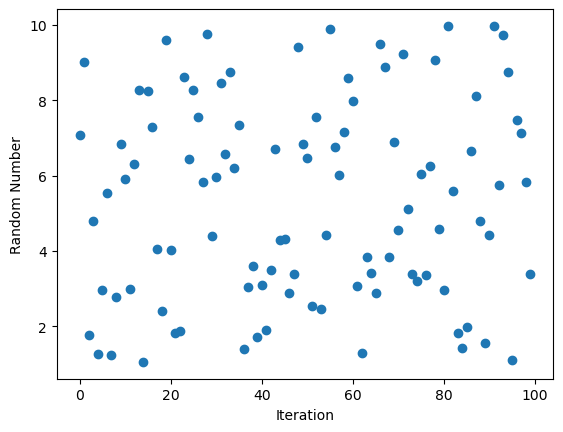

In [5]:
from random import uniform

results = np.empty(N)

for i in range(N):
    results[i] = uniform(1, 10) # random numbers within [1,10)

plt.figure()
plt.plot(results,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

To obtain random *integers* from the built-in generator, use the `randrange()` function.

Text(0, 0.5, 'Random Number')

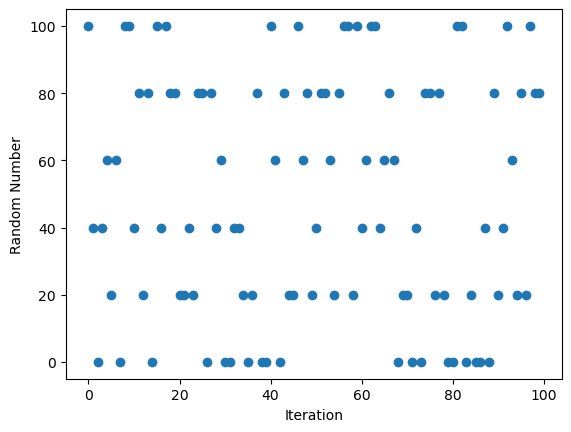

In [6]:
from random import randrange

results = np.empty(N)

for i in range(N):
    results[i] = randrange(0, 101, 20) #random multiples of 20 between [0,100]

plt.figure()
plt.plot(results,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

Lastly, to choose a random element from a list, use the `choice()` function.

In [7]:
from random import choice

l = ['dog', 'cat', 'horse', 'bird']

choice(l)

'bird'

## Biased coins

We often encounter situations in physics where we want to make some event occur randomly with probability $p$.  To do so, we simply draw a random number according to a uniform probability density in [0,1), and make the event happen if this value is less than $p$.  A classic example is radioactive decay.  

Decay of thallium 208 to lead 208 occurs with a half life $\tau = 3.053$ minutes. We can simulate the number of thallium atoms remaining as a function of time using random numbers, capturing the random nature of radioactive decay.  The number of thallium atoms remaining $N(t)$ after some time interval $t$ is given by $$N(t) = N(0)2^{-t/\tau}.$$  The fraction of thallium atoms remaining is therefore $N(t)/N(0) = 2^{-t/\tau}.$  The fraction which have decayed, which is also the probability $p(t)$ that a particular atom has decayed, is given by $$p(t) = 1-2^{-t/\tau}\tag{2}.$$

To simulate the decay of a collection of thallium atoms, we can  divide time into short intervals and independently apply Equation 2 to each atom in the ensemble to determine if it decays during each time step.

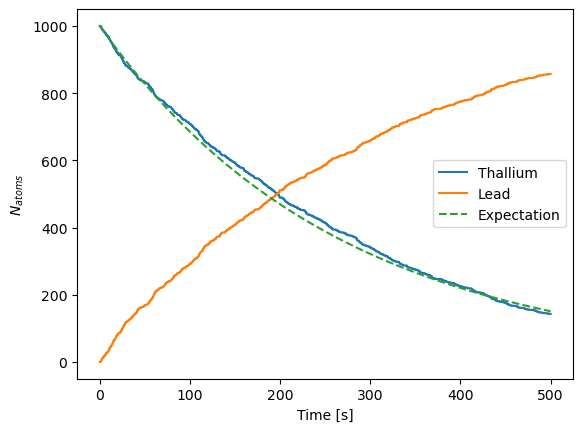

In [22]:
import numpy as np

N = 10000             # Number of time steps to perform
n0Tl = 1000         # Initial number of thallium atoms
n0Pb = 0             # Initial number of lead atoms
tau = 3.053*60       # Half life of thallium in seconds
tMax = 500           # Total time interval

h = tMax/N           # Size of time-step in seconds
p = 1 - 2**(-h/tau)  # Probability of decay in a given time step

seed(8675309)

# Lists of plot points
tValues = np.arange(0,tMax,h)
nTlValues = []
nPbValues = []

# Main loop
nTl = n0Tl
nPb = n0Pb
for t in tValues:
    nTlValues.append(nTl)
    nPbValues.append(nPb)

    # Calculate the number of atoms that decay
    decay = 0
    for i in range(nTl):
        if random()<p: # Check if atom decays during this interval
            decay += 1
    nTl -= decay
    nPb += decay

# Make the graph
plt.figure()
plt.plot(tValues,nTlValues,label="Thallium")
plt.plot(tValues,nPbValues,label="Lead")
plt.plot(tValues,n0Tl*2**(-tValues/tau),linestyle="dashed",label="Expectation")
plt.xlabel("Time [s]")
plt.ylabel("$N_{atoms}$")
plt.legend(loc="best")
#plt.show()

Our modeling of the thallium atoms matches the general expectation for exponential decay, while capturing the statistical fluctuations present in an actual physical system.

### Exercise

The isotope $^{213}$Bi decays to stable $^{209}$Bi via one of two different routes, with probabilities and half-lives as shown in the figure. (Technically, $^{209}$Bi isn't really stable, but it has a half-life of more than $10^{19}$ years, a billion times the age of the universe, so it might as well be.)

<center>
<div>
    <img src="https://raw.githubusercontent.com/jstupak/ComputationalPhysics/master/Images/bismuthDecay.png" width="150"/>
</div>
</center>

Starting with a sample consisting of 10,000 atoms of $^{213}$Bi, simulate the decay of the atoms (as above) by dividing time into slices of length $\delta t = 1$ s each.  On each step doing the following:
1) For each atom of $^{209}$Pb in turn, decide at random, with the appropriate probability, whether it decays or not (the probability can be calculated from Equation 2). Count the total number that decay, subtract it from the number of $^{209}$Pb atoms, and add it to the number of $^{209}$Bi atoms.
2) Now do the same for $^{209}$Tl, except that decaying atoms are subtracted from the total for $^{209}$Tl and added to the total for $^{209}$Pb.
3) For $^{213}$Bi the situation is more complicated: when a $^{213}$Bi atom decays you have to decide at random with the appropriate probability the route by which it decays. Count the numbers that decay by each route and add and subtract accordingly.

Note that you have to work up the chain from the bottom like this, not down from the top, to avoid inadvertently making the same atom decay twice on a single step. 

Keep track of the number of atoms of each of the four isotopes at all times for 20,000 seconds and make a single graph showing the four populations as a function of time on the same axes.

In [12]:
# Random Walk 1
# Very basic 1D random walk
#
import numpy as np

n_steps  = 200     # Number of steps
position = 0     # Current position along the x-axis
verbose  = False  # Detailed print

if verbose:
    print("Flip details:")

for step in range(n_steps):

    # randomly pick 0 or 1
    coin = np.random.randint(0,2) # random integer in [low,high)

    # if 0(heads), move one step in the +x direction
    if coin==0:
        position+=1
        if verbose:
            print(" Heads")

    # if 1(tails), move one step  in the -x direcgtion
    if coin==1:
        position-=1
        if verbose:
            print(" Tails")

print("Final position:", position)

Final position: 8


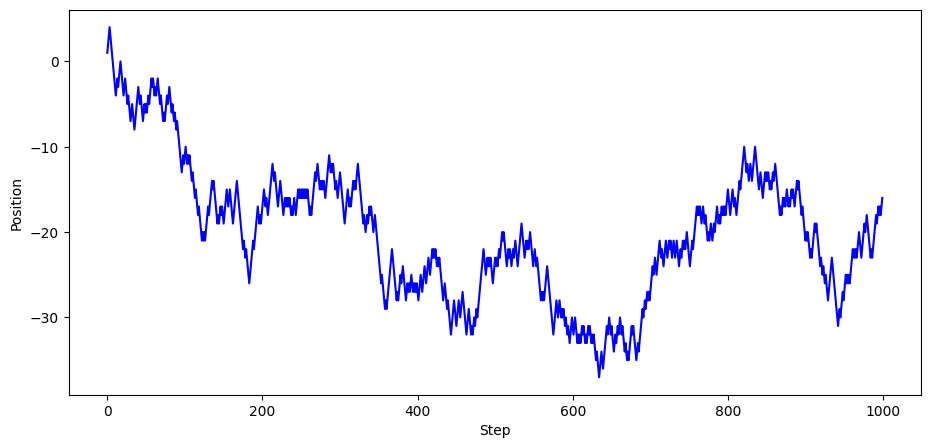

In [49]:
# Random Walk 2
# Very basic 1D random walk
# Plot the drunk person's path
import numpy as np
import matplotlib.pyplot as plt

n_steps  = 1000     # Number of steps
position = 0     # Current position along the x-axis
verbose  = False  # Detailed print
position = 0     # Set initial position

position_tracker = np.zeros(n_steps)
step_tracker = np.zeros(n_steps)

if verbose:
    print("Flip details:")

for step in range(n_steps):

    # randomly pick 0 or 1
    coin = np.random.randint(0,2) # random integer in [low,high)

    # if 0(heads), move one step in the +x direction
    if coin==0:
        position+=1
        if verbose:
            print(" Heads")

    # if 1(tails), move one step  in the -x direcgtion
    if coin==1:
        position-=1
        if verbose:
            print(" Tails")

    # Save the position for this step in an array
    position_tracker[step] = position
    # Save the step number
    step_tracker[step]     = step

#print(step_tracker)
#print(position_tracker)
plt.rcParams['figure.figsize'] = 11, 5 # Make the plot wider (11 inches wide, 5 inches tall)
plt.plot(step_tracker,position_tracker,"b-")
plt.xlabel("Step")
plt.ylabel("Position")
plt.show()

(5, 200)


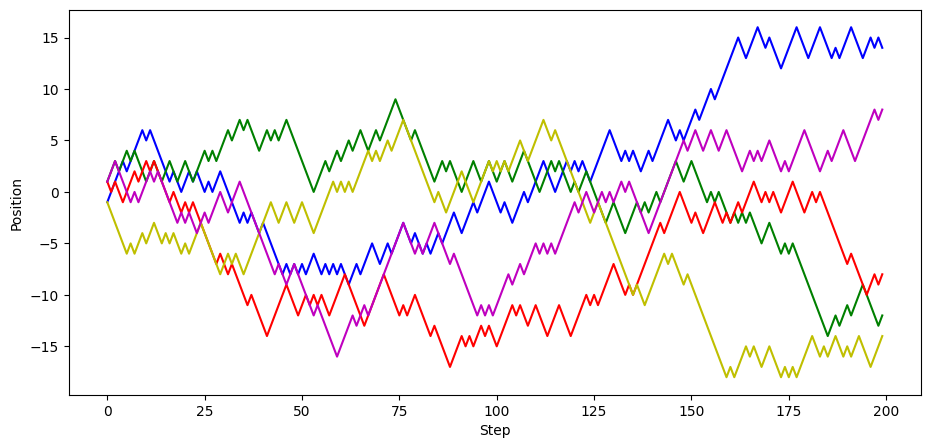

In [50]:
# Random Walk 3
# Very basic 1D random walk
# Plot multiple drunk people's paths
import numpy as np
import matplotlib.pyplot as plt

n_people = 5      # Number of people

n_steps  = 200    # Number of steps
position = 0      # Current position along the x-axis
verbose  = False  # Detailed print

position_tracker = np.zeros(shape=(n_people,n_steps))
step_tracker     = np.zeros(n_steps)

print(position_tracker.shape)

for drunk in range(n_people):
    position = 0     # Set initial position
    for step in range(n_steps):

        # randomly pick 0 or 1
        coin = np.random.randint(0,2) # random integer in [low,high)

        # if 0(heads), move one step in the +x direction
        if coin==0:
            position+=1

        # if 1(tails), move one step  in the -x direcgtion
        if coin==1:
            position-=1

        # Save the position for this step in an array
        #print("step",step,"drunk",drunk)

        position_tracker[drunk][step] = position
        # Save the step number
        step_tracker[step]     = step

    colors = ('b', 'g', 'r','y', 'm', 'c', 'k')
    color = colors[drunk]
    plt.plot(step_tracker,position_tracker[drunk,:],"-",color=color)



plt.rcParams['figure.figsize'] = 11, 8 # Make the plot wider (11 inches wide, 5 inches tall)
plt.xlabel("Step")
plt.ylabel("Position")
plt.show()

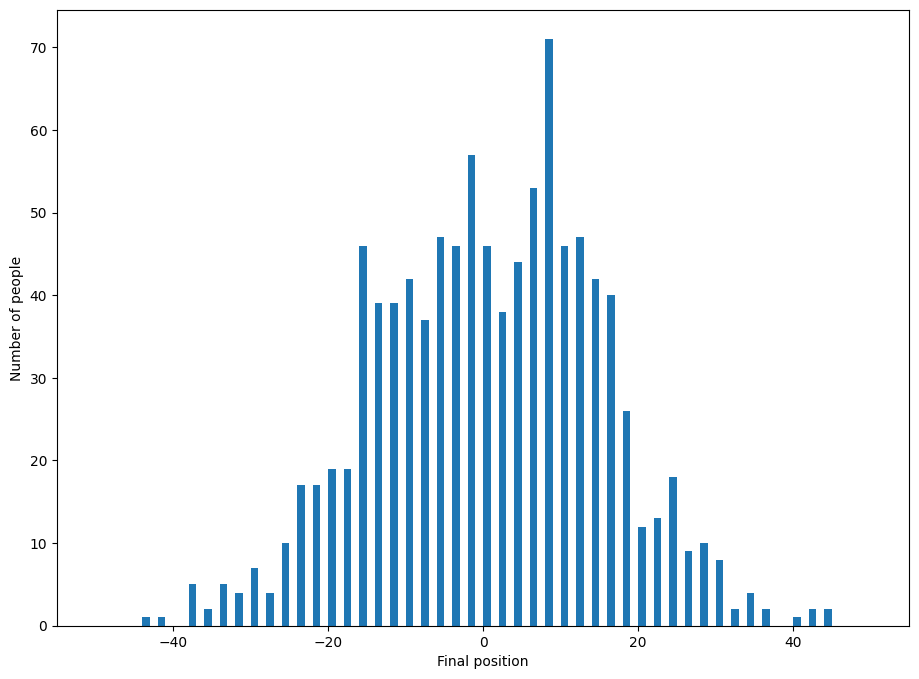

In [51]:
# Random Walk 4
# Very basic 1D random walk
# Plot the final position of many drunkards
import numpy as np
import matplotlib.pyplot as plt

n_steps  = 200    # Number of steps
n_people = 1000   # Number of people

final_positions = np.zeros(n_people)
y = final_positions

for drunk in range(n_people):

    position = 0     # Set position along the x-axis to zero

    for step in range(n_steps):

        # randomly pick 0 or 1
        coin = np.random.randint(0,2) # random integer in [low,high)

        # if 0(heads), move one step in the +x direction
        if coin==0:
            position+=1

        # if 1(tails), move one step  in the -x direcgtion
        if coin==1:
            position-=1

    final_positions[drunk] = position


#plt.hist(final_positions, bins=2*n_steps,  range=(-n_steps,n_steps))#
plt.hist(final_positions, bins=100,  range=(-50,50))
plt.xlabel("Final position")
plt.ylabel("Number of people")
plt.show()


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.
 91. 92. 93. 94. 95. 96. 97. 98. 99.]
[ 0.99960792  1.37395196  1.75225569  2.05546686  2.21824796  2.39198662
  2.64954638  2.69285276  2.97997584  3.36089512  3.15340831  3.49384831
  3.68818872  3.51511252  3.90126954  4.03559165  4.25731559  4.30284743
  4.18978567  4.67037472  4.64102747  4.76638899  4.73535638  4.70888692
  5.06219083  4.81551493  5.2712048   5.33032232  4.9514507   5.58891904
  5.44313292  5.53770494  5.94938114  5.71292429  6.07536007  6.37981191
  6.03121878  6.15508375  6.30994643  5.92056619  6.41118523  6.54663394
  6.55426579  6.73324409  6.86484843  6.93290819  6.52401226  7.02748888
  6.97770048 

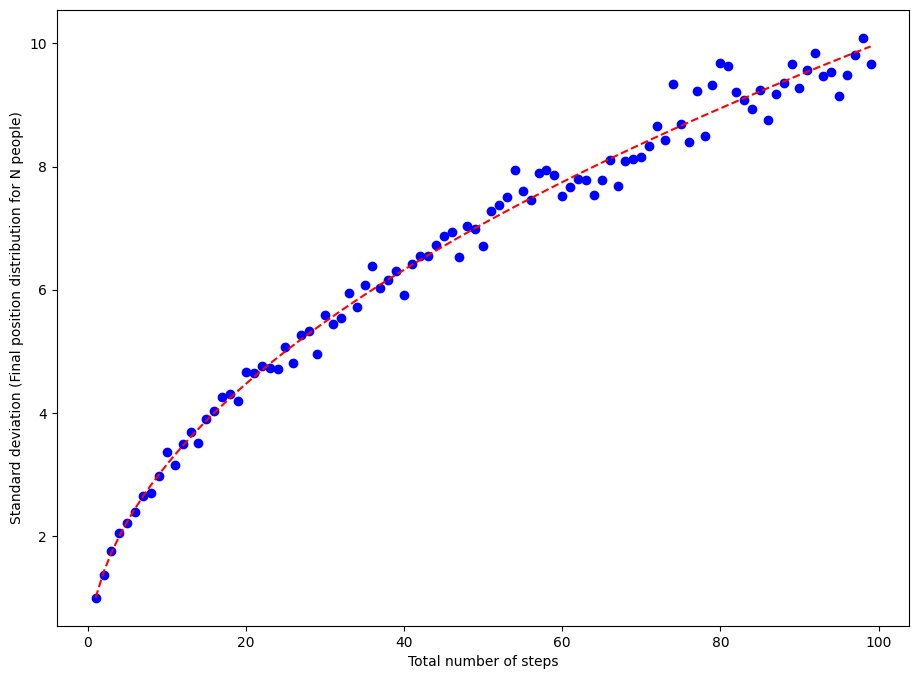

In [52]:
# Random Walk 5
# Very basic 1D random walk
# Plot standard deviation for different number of steps
import numpy as np
import matplotlib.pyplot as plt

n_steps  = 100    # Number of steps
n_people = 500   # Number of people


step_min = 1
step_max = n_steps

a_n_steps = np.zeros(step_max-step_min)
a_pos_std = np.zeros(step_max-step_min)
model     = np.zeros(step_max-step_min)


count =0
for n_steps in range(step_min,step_max):

    final_positions = np.zeros(n_people)

    for drunk in range(n_people):

        position = 0     # Set position along the x-axis to zero

        for step in range(n_steps):

            # randomly pick 0 or 1
            coin = np.random.randint(0,2) # random integer in [low,high)

            # if 0(heads), move one step in the +x direction
            if coin==0:
                position+=1

            # if 1(tails), move one step  in the -x direcgtion
            if coin==1:
                position-=1

        final_positions[drunk] = position

    final_pos_mean  = np.mean(final_positions)  # mean
    final_pos_std   = np.std(final_positions)   # standard deviation

    a_n_steps[count] = n_steps
    a_pos_std[count] = final_pos_std
    model[count]     = np.sqrt(n_steps)
    count+=1

print(a_n_steps)
print(a_pos_std)

plt.plot(a_n_steps,a_pos_std,"bo",linestyle='')
plt.plot(a_n_steps,model,"r--")
plt.xlabel("Total number of steps")
plt.ylabel("Standard deviation (Final position distribution for N people)")
plt.show()


### Making your own pseudo random number generator

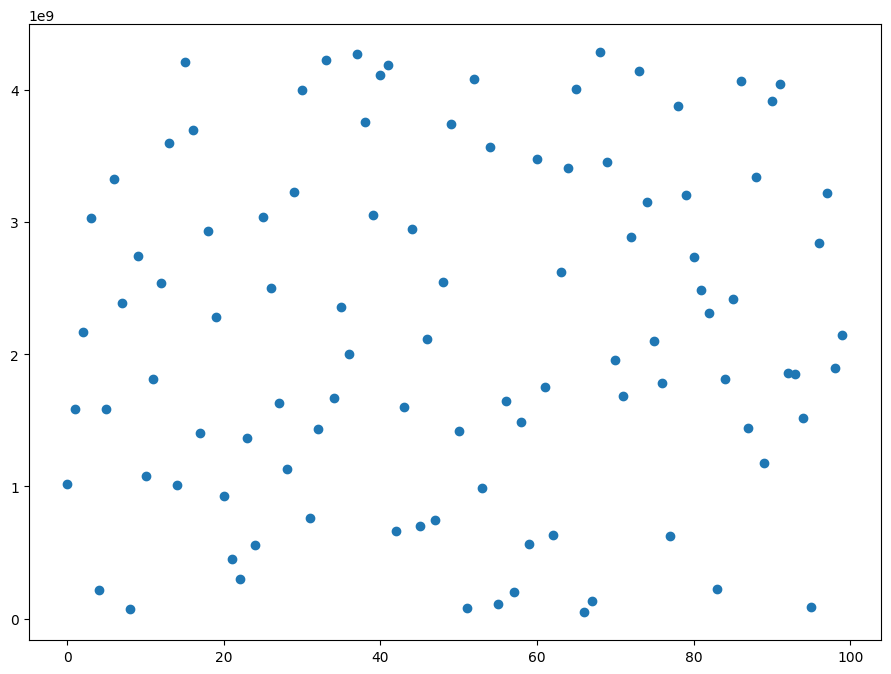

In [55]:
# Linear congruential random number generator
# Caution: This is not actually random

from pylab import plot,show

N = 100
a = 1664525
c = 1013904223
m = 4294967296
x = 1
results = []

for i in range(N):
    x = (a*x+c)%m
    results.append(x)
plot(results,"o")
show()


### Examples: Using random numbers in simulations and calculations


#### Monte Carlo Methods
* Computational techniques using random sampling
    * Monte Carlo Integration - "Throw many darts"
    * Optimization - minimize or maximize in a N dimensional space
    * Simulation
* Very wide usage in many fields
    

#### Random walk
* Simulate the path of a particle after N random steps
* Related to many real-world effects
    * Brownian motion
    * Diffusion
    * Ecology (foraging animals)
    * Economics (stock prices)
